# TP : Résolution Numérique de l'Équation de la Chaleur 1D

**Simulation de la Diffusion Thermique dans une Barre Métallique**

---

### 🎯 Objectifs Pédagogiques

À l'issue de ce TP, vous serez capables de :
- Comprendre le phénomène physique de diffusion thermique
- Discrétiser une équation aux dérivées partielles (EDP) par la méthode des **différences finies**
- Implémenter un schéma numérique **Euler explicite** en Python
- Visualiser l'évolution temporelle d'un champ de température
- Analyser la **stabilité numérique** d'un schéma
- Analyser la sensibilité des résultats à la finesse de la grille.
---



## 📚 Rappels Théoriques

### Le Phénomène Physique

La conduction thermique dans un milieu solide est gouvernée par la **loi de Fourier**. Pour une barre homogène de longueur $L$, la température $T(x,t)$ évolue selon l'**équation de la chaleur 1D** :

$$\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}$$

où :
- $T(x,t)$ : température en °C (ou K) au point $x$ et à l'instant $t$
- $\alpha = \frac{k}{\rho c_p}$ : **diffusivité thermique** (m²/s)
- $k$ : conductivité thermique (W/m·K)
- $\rho$ : masse volumique (kg/m³)
- $c_p$ : capacité thermique massique (J/kg·K)

> 💡 **Interprétation physique** : Cette équation traduit que la variation temporelle de température en un point est proportionnelle à la courbure spatiale du profil de température. Un point "plus froid que ses voisins" va se réchauffer.

### Discrétisation par Différences Finies

Pour résoudre numériquement cette équation, on discrétise le domaine :

**Dans l'espace** : on divise la barre $[0, L]$ en $N$ intervalles de taille $\Delta x = L/N$, ce qui donne $N+1$ nœuds aux positions $x_i = i \cdot \Delta x$, avec $i = 0, 1, ..., N$.

**Dans le temps** : on avance par pas de temps $\Delta t$, aux instants $t^n = n \cdot \Delta t$, avec $n = 0, 1, 2, ...$

On note $T_i^n \approx T(x_i, t^n)$.

**Approximation des dérivées :**

$$\frac{\partial T}{\partial t} \approx \frac{T_i^{n+1} - T_i^n}{\Delta t} \quad \text{(différence finie avant)}$$

$$\frac{\partial^2 T}{\partial x^2} \approx \frac{T_{i+1}^n - 2T_i^n + T_{i-1}^n}{\Delta x^2} \quad \text{(différence finie centrée)}$$

En substituant dans l'équation de la chaleur, on obtient le **schéma FTCS** (*Forward Time, Centered Space*) :

$$\boxed{T_i^{n+1} = T_i^n + r\left(T_{i+1}^n - 2T_i^n + T_{i-1}^n\right)}$$

où $r = \dfrac{\alpha \Delta t}{\Delta x^2}$ est appelé le **nombre de Fourier discret** (ou paramètre de stabilité).

### Condition de Stabilité

Le schéma explicite FTCS n'est **stable** que si :

$$\boxed{r = \frac{\alpha \Delta t}{\Delta x^2} \leq \frac{1}{2}}$$

> ⚠️ Si cette condition n'est pas respectée, la solution numérique **diverge** et n'a aucun sens physique !

---


## 🔧 Mise en Place du Code de Base 
### Contexte Physique

On considère une **barre de cuivre** de longueur $L = 1$ m, initialement à une température uniforme $T_0 = 0$°C. Les deux extrémités sont maintenues à des températures constantes :
- $T(0, t) = 100$ °C (extrémité gauche chauffée)
- $T(L, t) = 0$ °C (extrémité droite froide)

**Paramètres du cuivre :**
- Diffusivité thermique : $\alpha = 1.11 \times 10^{-4}$ m²/s

### Questions

**Q1.1 – Paramètres de simulation**

Complétez et exécutez le code suivant pour définir les paramètres :

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Paramètres physiques ---
L     = 1.0          # Longueur de la barre (m)
alpha = 1.11e-4      # Diffusivité thermique du cuivre (m²/s)
T_gauche = 100.0     # Température à x=0 (°C)
T_droite = 0.0       # Température à x=L (°C)
T_init   = 0.0       # Température initiale (°C)

# --- Paramètres numériques ---
N  = 20              # Nombre d'intervalles spatiaux
dx = L / N           # Pas spatial (m)
r = 0.4              # Nombre de Fourier discret
dt = r * dx**2 / alpha       # Pas de temps (à calculer pour r = 0.4)          

t_fin = 3000         # Durée de simulation (s)
nt    = int(t_fin / dt)  # Nombre de pas de temps

print(f"dx = {dx:.4f} m")
print(f"dt = {dt:.4f} s")
print(f"r  = {r:.4f}  (doit être ≤ 0.5 pour Euler)")
print(f"Nombre de pas de temps : {nt}")

dx = 0.0500 m
dt = 9.0090 s
r  = 0.4000  (doit être ≤ 0.5 pour Euler)
Nombre de pas de temps : 332


> 📝 **Travail demandé** : Calculez $\Delta t$ pour obtenir $r = 0.4$. Vérifiez que la condition de stabilité est respectée.

---

**Q1.2 – Initialisation du domaine**

Profil initial de température :
[100.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.]


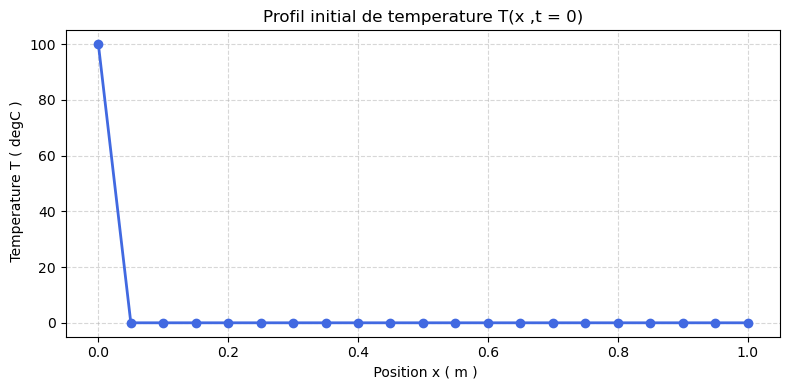

In [2]:
# --- Création de la grille spatiale ---
x = np.linspace(0, L, N+1)   # N+1 points de x=0 à x=L

# --- Condition initiale ---
T = np.ones(N+1) * T_init

# --- Application des conditions aux limites ---
T[0]  = T_gauche
T[-1] = T_droite

print("Profil initial de température :")
print(T)
#---Visualisation du profil initial ---
fig , ax = plt.subplots ( figsize = (8 , 4) )
ax.plot(x , T ,'o-' , color ='royalblue' , linewidth = 2 ,markersize = 6)
ax.set_xlabel(' Position x ( m )')
ax.set_ylabel(' Temperature T ( degC )')
ax.set_title("Profil initial de temperature T(x ,t = 0)")
ax.grid ( True , linestyle ='--' , alpha = 0.5)
plt.tight_layout ()
plt.show ()



> 📝 **Travail demandé** : 
> - Tracez le profil initial de température $T(x, t=0)$ avec `matplotlib`.
> - Combien y a-t-il de nœuds intérieurs (nœuds dont la température est inconnue) ?

---

**Boucle temporelle principale**

In [3]:
# --- Stockage de la solution ---
# On sauvegarde le profil tous les "save_step" pas de temps
save_frac = 10
save_step = max(1, nt // save_frac)
T_save = [T.copy()]
t_save = [0.0]

T_new = T.copy()

for n in range(1, nt+1):
    # Mise à jour des noeuds intérieurs (i = 1 à N-1)
    for i in range(1, N):
        T_new[i] = T[i] + r * (T[i+1] - 2*T[i] + T[i-1])
        
    # Mise à jour
    T = T_new.copy()
    
    # Sauvegarde périodique
    if n % save_step == 0:
        T_save.append(T.copy())
        t_save.append(n * dt)

T_save = np.array(T_save)
print(f"Nombre de profils sauvegardés : {len(T_save)}")

Nombre de profils sauvegardés : 11


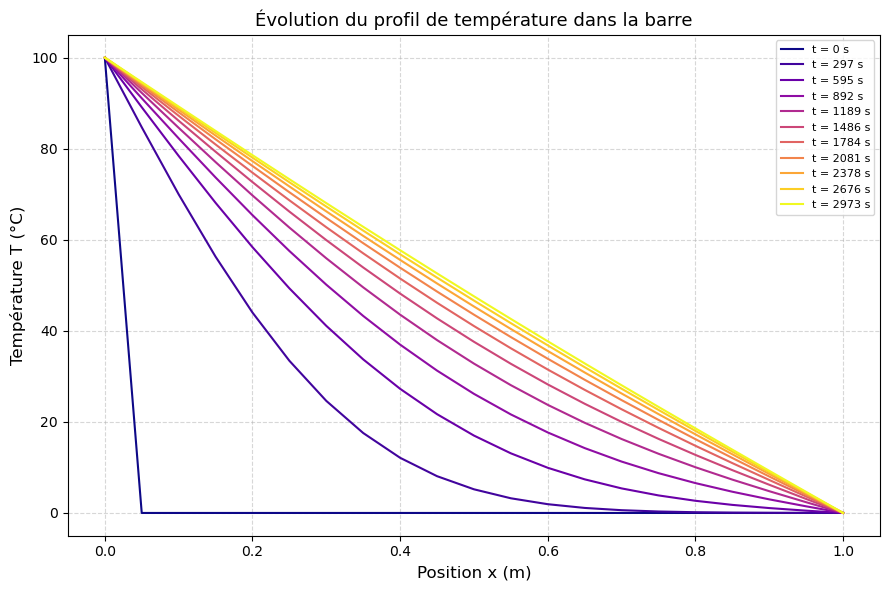

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = cm.plasma(np.linspace(0, 1, len(T_save)))

for k, (T_k, t_k) in enumerate(zip(T_save, t_save)):
    ax.plot(x, T_k, color=colors[k], label=f't = {t_k:.0f} s')

ax.set_xlabel('Position x (m)', fontsize=12)
ax.set_ylabel('Température T (°C)', fontsize=12)
ax.set_title("Évolution du profil de température dans la barre", fontsize=13)
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

> ⚡ **Remarque** : La double boucle `for` est fonctionnelle mais lente. Nous l'optimiserons dans la Partie 2.

---

**Q1.4 – Visualisation des résultats**

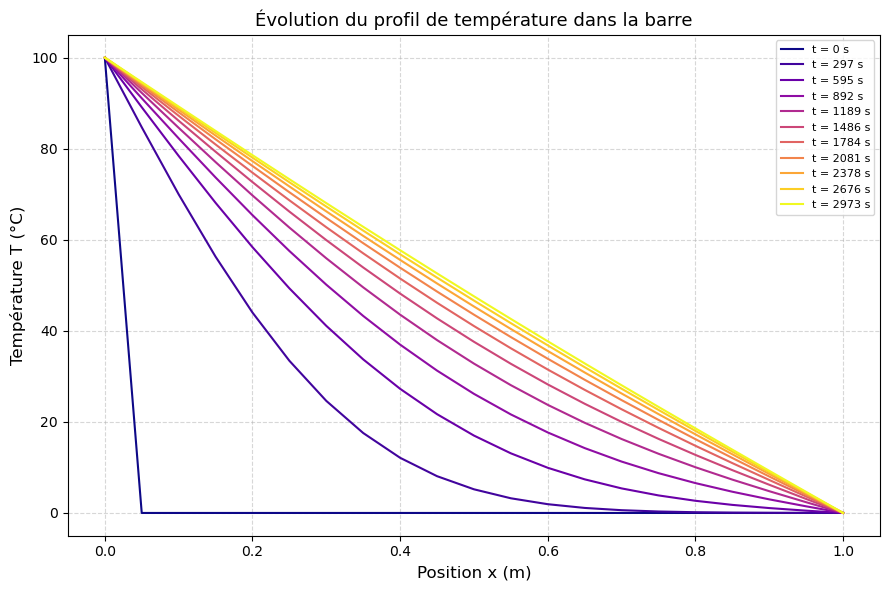

In [5]:
# --- Tracé des profils de température à différents instants ---
def tracer_T_x(x, T, t):
    fig, ax = plt.subplots(figsize=(9, 6))

    colors = cm.plasma(np.linspace(0, 1, len(T)))

    for k, (T_k, t_k) in enumerate(zip(T, t)):
        ax.plot(x, T_k, color=colors[k], label=f't = {t_k:.0f} s')

    ax.set_xlabel('Position x (m)', fontsize=12)
    ax.set_ylabel('Température T (°C)', fontsize=12)
    ax.set_title("Évolution du profil de température dans la barre", fontsize=13)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

tracer_T_x(x, T_save, t_save)



> 📝 **Travail demandé** :
> - Décrivez qualitativement l'évolution du profil de température.
> - Vers quel profil le système semble-t-il converger quand $t \to \infty$ ?

---


### Encapsulation dans une fonction

In [6]:
def simulation_chaleur(L, alpha, N, r, t_fin, T_gauche, T_droite, T_init, save_frac=10):
    """
    Résout l'équation de la chaleur 1D par schéma FTCS explicite (version vectorisée).
    
    Paramètres :
    ------------
    L          : longueur de la barre (m)
    alpha      : diffusivité thermique (m²/s)
    N          : nombre d'intervalles spatiaux
    r          : nombre de Fourier discret (r <= 0.5 pour la stabilité)
    t_fin      : durée totale de simulation (s)
    T_gauche   : température à x=0 (°C)
    T_droite   : température à x=L (°C)
    T_init     : température initiale uniforme (°C)
    
    Retourne :
    ----------
    x, t_save, T_save
    """

    dx = L / N
    dt = r * dx**2 / alpha
    nt = int(t_fin / dt)
    
    x = np.linspace(0, L, N+1)
    T = np.ones(N+1) * T_init
    T[0]  = T_gauche
    T[-1] = T_droite
    
    save_step = max(1, nt // save_frac)
    T_save, t_save = [T.copy()], [0.0]

    T_new = T.copy()

    for n in range(1,nt+1):
        # Mise à jour des noeuds intérieurs (i = 1 à N-1)
        for i in range(1, N):
            T_new[i] = T[i] + r * (T[i+1] - 2*T[i] + T[i-1])
        # Mise à jour
        T = T_new.copy()
        # Sauvegarde périodique
        if n % save_step == 0:
            T_save.append(T.copy())
            t_save.append(n * dt)

    return x, np.array(t_save), np.array(T_save)


**Test de la fonction** 

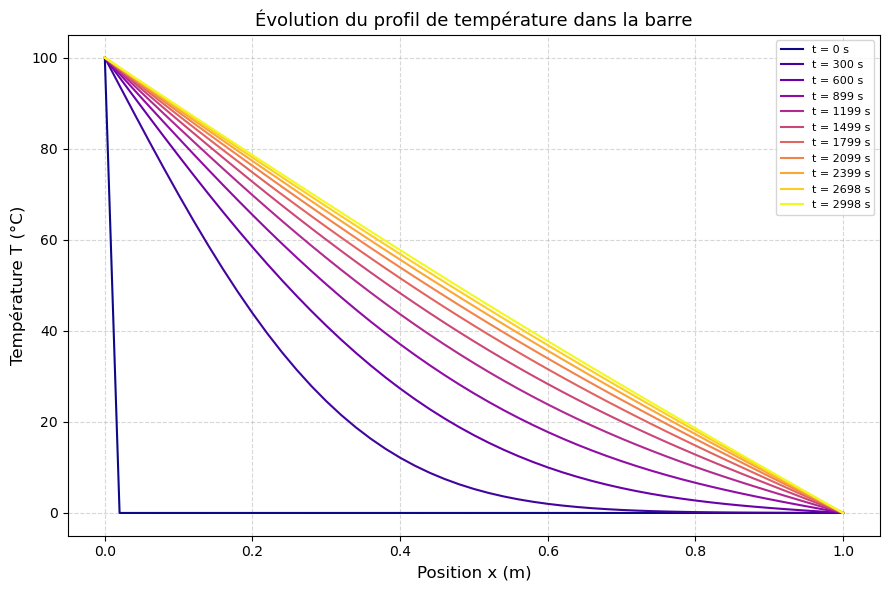

In [7]:

x, t_save, T_save = simulation_chaleur(L, alpha, N=50, r=0.4, t_fin=3000,
                                        T_gauche=100, T_droite=0, T_init=0)

tracer_T_x(x, T_save, t_save)
    


## ⚡ Optimisation avec NumPy

La double boucle Python est très lente pour des grandes grilles. NumPy permet de **vectoriser** les calculs.

**Version vectorisée**

In [8]:
def simulation_chaleur_vect(L, alpha, N, r, t_fin, T_gauche, T_droite, T_init, save_frac=10):
    """
    Résout l'équation de la chaleur 1D par schéma FTCS explicite (version vectorisée).
    
    Paramètres :
    ------------
    L          : longueur de la barre (m)
    alpha      : diffusivité thermique (m²/s)
    N          : nombre d'intervalles spatiaux
    r          : nombre de Fourier discret (r <= 0.5 pour la stabilité)
    t_fin      : durée totale de simulation (s)
    T_gauche   : température à x=0 (°C)
    T_droite   : température à x=L (°C)
    T_init     : température initiale uniforme (°C)
    
    Retourne :
    ----------
    x, t_save, T_save
    """
    dx = L / N
    dt = r * dx**2 / alpha
    nt = int(t_fin / dt)
    
    x = np.linspace(0, L, N+1)
    T = np.ones(N+1) * T_init
    T[0]  = T_gauche
    T[-1] = T_droite
    
    save_every = max(1, nt // save_frac)
    T_save, t_save = [T.copy()], [0.0]
    
    for n in range(nt):
        # ---- Version vectorisée : une seule ligne ! ----
        T[1:-1] = T[1:-1] + r * (T[2:] - 2*T[1:-1] + T[:-2])
        
        # Les conditions aux limites sont automatiquement préservées
        # car on ne touche pas T[0] et T[-1]
        
        if (n+1) % save_every == 0:
            T_save.append(T.copy())
            t_save.append((n+1) * dt)
    
    return x, np.array(t_save), np.array(T_save)

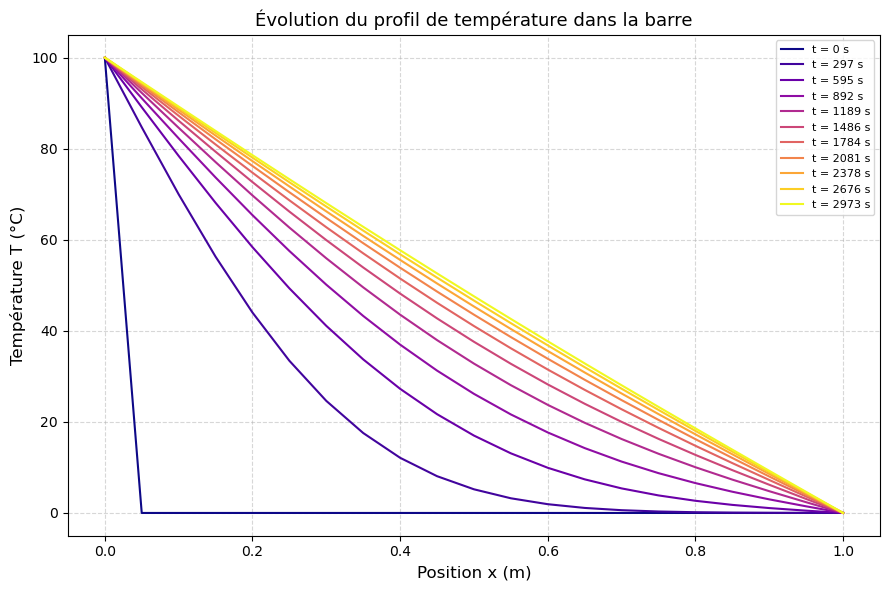

In [9]:
x, t_save, T_save = simulation_chaleur_vect(L, alpha, N, r=0.4,
                                        t_fin=3000,T_gauche=100, T_droite=0, T_init=0)

# --- Tracé des profils de température à différents instants ---
tracer_T_x(x, T_save, t_save)

> 📝 **Travail demandé** :
> - Expliquez ligne par ligne ce que fait `T[1:-1] = T[1:-1] + r * (T[2:] - 2*T[1:-1] + T[:-2])`.
> - Appelez cette fonction avec les mêmes paramètres qu'en Partie 1 et vérifiez que vous obtenez les mêmes résultats.

---

### Comparaison des temps de calcul

In [10]:
import time

# Mesure du temps pour la version avec boucle
debut = time.time()
x, t_save, T_save = simulation_chaleur(L, alpha, N=40, r=0.4,
                                        t_fin=3000,
                                        T_gauche=100, T_droite=0, T_init=0)
fin   = time.time()
print(f"Temps avec boucle for : {fin - debut:.3f} s")

# Mesure du temps pour la version vectorisée
debut = time.time()
x, t_save, T_save = simulation_chaleur_vect(L, alpha, N=40, r=0.4,
                                        t_fin=3000,
                                        T_gauche=100, T_droite=0, T_init=0)
fin   = time.time()
print(f"Temps version vectorisée : {fin - debut:.3f} s")

Temps avec boucle for : 0.017 s
Temps version vectorisée : 0.003 s


> 📝 **Travail demandé** : Comparez les temps de calcul obtenus. Qu'en concluez-vous sur l'intérêt de la vectorisation NumPy ?
---

## 📊 Analyse de la Stabilité Numérique

### Influence du paramètre $r$

Testez trois valeurs du paramètre de Fourier :

| Cas | Valeur de $r$ | Commentaire |
|-----|--------------|-------------|
| A   | $r = 0.4$    | Stable      |
| B   | $r = 0.5$    | Limite de stabilité |
| C   | $r = 0.6$    | Instable    |

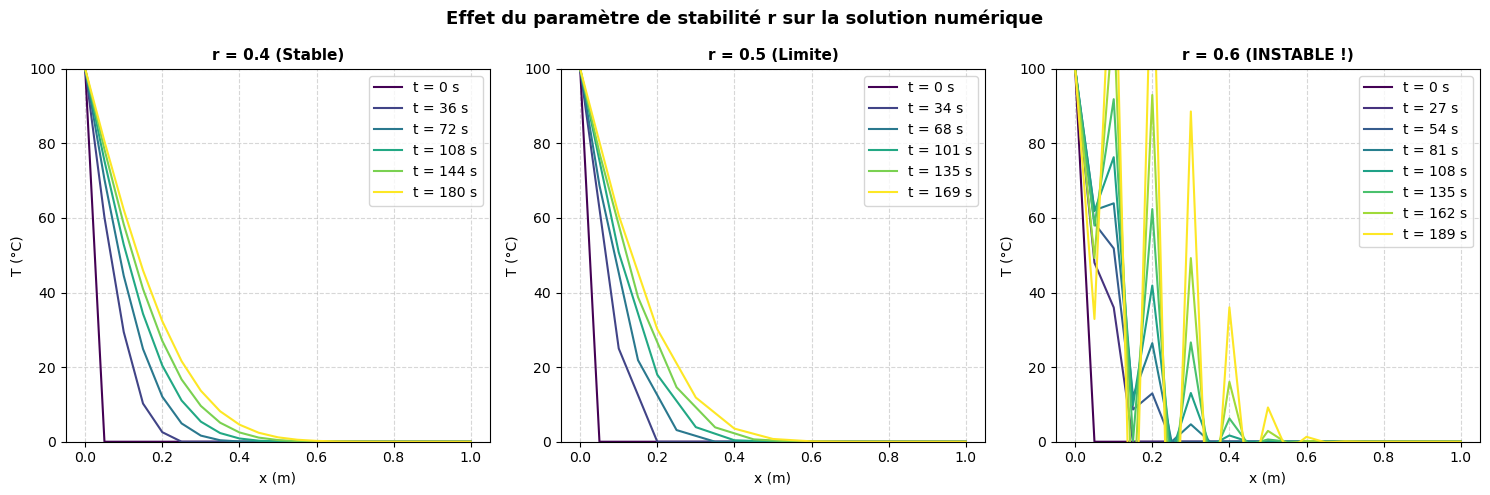

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

r_values   = [0.4, 0.5, 0.6]
titres     = ['r = 0.4 (Stable)', 'r = 0.5 (Limite)', 'r = 0.6 (INSTABLE !)']

for ax, r_val, titre in zip(axes, r_values, titres):
    x, t_sv, T_sv = simulation_chaleur_vect(L=1.0, alpha=1.11e-4, N=20, r=r_val,
                                        t_fin=200, T_gauche=100, T_droite=0, T_init=0, save_frac=5)
    colors = cm.viridis(np.linspace(0, 1, len(T_sv)))
    for k in range(len(T_sv)):
        ax.plot(x, T_sv[k], color=colors[k] ,label=f't = {t_sv[k]:.0f} s')
    
    ax.set_title(titre, fontsize=11, fontweight='bold')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('T (°C)')
    if r_val > 0.5 :
        ax.set_ylim(0, 100)   # Fixer les axes pour la comparaison
    else :
        ax.set_ylim(0, 100)   # Fixer les axes pour la comparaison
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()
plt.suptitle("Effet du paramètre de stabilité r sur la solution numérique", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> 📝 **Travail demandé** :
> - Décrivez ce que vous observez pour chaque valeur de $r$.
> - Que se passe-t-il physiquement pour $r > 0.5$ ? Est-ce acceptable ?

---

### Q3.2 – Influence du raffinement spatial

Comparez les solutions pour différentes valeurs de $N$ (en gardant $r = 0.4$ fixé) :

1441.4414414414418
1441.4414414414418
1441.4414414414418
1441.4414414414414


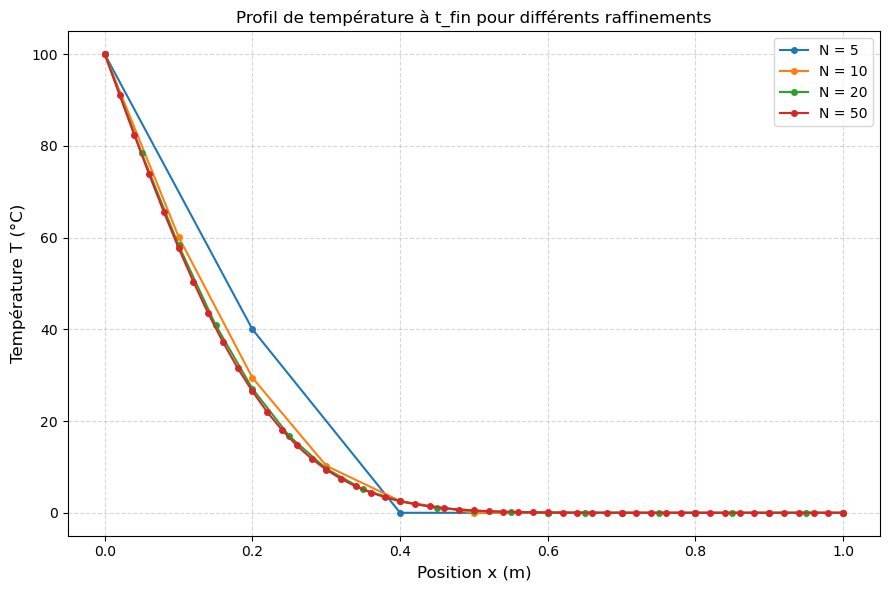

In [12]:
N_values = [5, 10, 20, 50]

fig, ax = plt.subplots(figsize=(9, 6))

for N_val in N_values:
    x_n, t_sv, T_sv = simulation_chaleur_vect(L=1.0, alpha=1.11e-5, 
                                              N=N_val, r=0.4,
                                          t_fin=1500, T_gauche=100, T_droite=0, 
                                          T_init=0, save_frac=10)
    # On trace uniquement le profil final (état stationnaire)
    ax.plot(x_n, T_sv[-1], marker='o', markersize=4, label=f'N = {N_val}')
    print(t_sv[-1])
ax.set_xlabel('Position x (m)', fontsize=12)
ax.set_ylabel('Température T (°C)', fontsize=12)
ax.set_title("Profil de température à t_fin pour différents raffinements", fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
